In [2]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [3]:
#Function 4
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 4.csv') 
columns = ['Input 1', 'Input 2', 'Input 3', 'Input 4', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.448159, 0.518735, 0.367877, 0.410965,
                      -1.5194726783305934])
data.loc[len(data)] = new_data7
#Add Week 8's data to our pandas dataframe
new_data8 = np.array([0.404520, 0.368851, 0.432035, 0.470888,
                      -0.6709532563484824])
data.loc[len(data)] = new_data8
#Add Week 9's data to our pandas dataframe
new_data9 = np.array([0.376941, 0.344380, 0.389150, 0.371290,
                      0.3057430767883038])
data.loc[len(data)] = new_data9
#Add Week 10's data to our pandas dataframe
new_data10 = np.array([0.436862, 0.349205, 0.342986, 0.358299,
                      0.36952809492683203])
data.loc[len(data)] = new_data10
data

,Input 1,Input 2,Input 3,Input 4,Outputs
0,0.896981,0.725628,0.175404,0.701694,-22.108290
1,0.889356,0.499588,0.539269,0.508783,-14.601400
2,0.250946,0.033693,0.145380,0.494932,-11.699930
3,0.346962,0.006250,0.760564,0.613024,-16.053770
4,0.124871,0.129770,0.384400,0.287076,-10.069630
5,0.801303,0.500231,0.706645,0.195103,-15.487080
6,0.247708,0.060445,0.042186,0.441324,-12.681690
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049240
9,0.626071,0.586751,0.438806,0.778858,-12.741770


In [4]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2', 'Input 3', 'Input 4']])
Y = np.array(data[['Outputs']])

# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Input 3,Input 4,Outputs
Input 1,1.000000,0.312378,0.147068,0.083846,-0.338576
Input 2,0.312378,1.000000,-0.130135,0.106119,-0.286962
Input 3,0.147068,-0.130135,1.000000,-0.026132,-0.244385
Input 4,0.083846,0.106119,-0.026132,1.000000,-0.524502
Outputs,-0.338576,-0.286962,-0.244385,-0.524502,1.000000


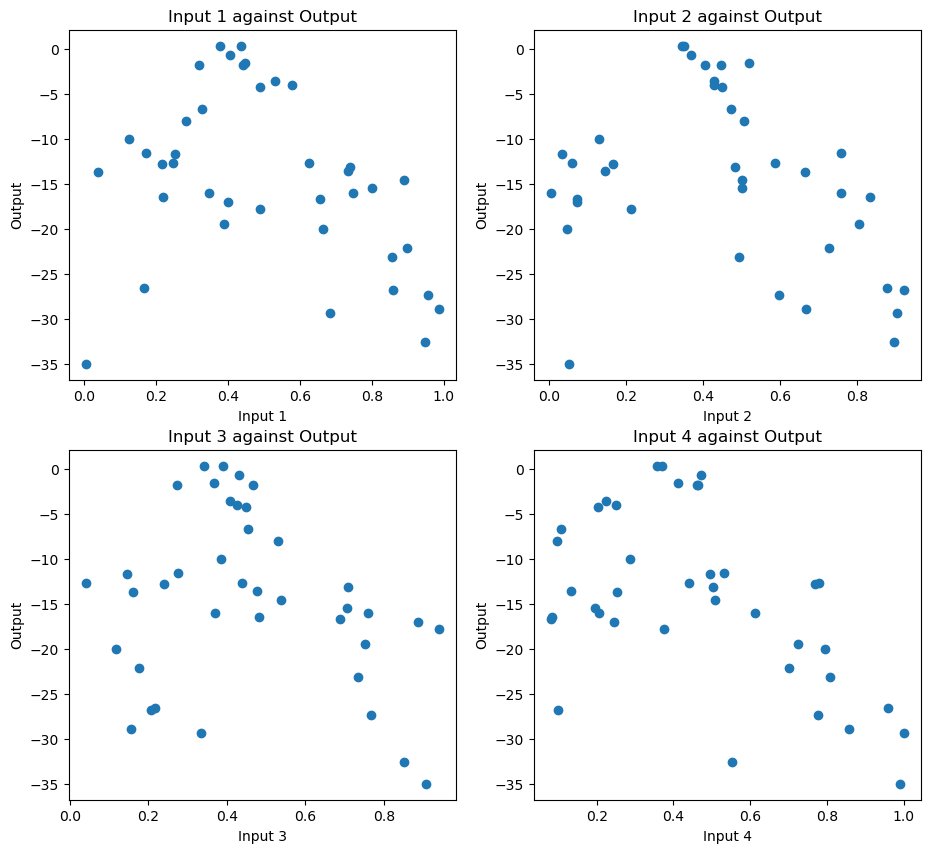

In [5]:
#Plotting each Input against the output
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,2, figsize = (11,10))

ax[0][0].scatter(X[:,0], Y)
ax[0][1].scatter(X[:,1], Y)
ax[1][0].scatter(X[:,2], Y)
ax[1][1].scatter(X[:,3], Y)

#Creating titles and axis labels
ax[0][0].set_title('Input 1 against Output')
ax[0][1].set_title('Input 2 against Output')
ax[1][0].set_title('Input 3 against Output')
ax[1][1].set_title('Input 4 against Output')

ax[0][0].set_xlabel('Input 1')
ax[0][0].set_ylabel('Output')

ax[0][1].set_xlabel('Input 2')
ax[0][1].set_ylabel('Output')

ax[1][0].set_xlabel('Input 3')
ax[1][0].set_ylabel('Output')

ax[1][1].set_xlabel('Input 4')
ax[1][1].set_ylabel('Output')

plt.show()

In [6]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)

Tuned RF Model: RandomForestRegressor(max_features=0.5, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [7]:
#Use latin hypercube sampling to create a grid 
d = 4
n = 40000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to predict outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 200 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [8]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)

gp.fit(X,Y)



#fit GP to candidate points suggested by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)

#fit GP to candidate points generated over entire domain
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [9]:
#Calculate UCB 
beta = 1.96 #set exploration parameter
#UCB for points selected by Random forest model
UCB = mu + beta*std
#UCB for entire domain
UCB_grid = mu_grid + beta*std_grid 
#Find point selected by random forest model that maximises UCB
X_next = X_candidates[np.argmax(UCB)]
#Find point over entire domain that maximises UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.410581 0.393007 0.429436 0.356452]
Pure GP model next suggested point: [0.410581 0.393007 0.429436 0.356452]
